# SIFT Implementation

## Step 0 : Imports

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, cos, sin, exp

## Step 1 : Scale Space Extrema Detection

### 1.1 Create Base Image

1) *Doubling the image size* - The original image is expanded in size to create more sample points and the results showed that doubling the image increases the no. of stable keypoints by almost a factor of 4 and no significant further improvements were found with a larger expansion factor

2) *Pre-smoothing the image* - Applying a Gaussian blur on original image before extrema detection will effectively discard highest spatial frequencies. We assume the original image has a blur of atleast 0.5 (minimum sigma value needed to prevent significant aliasing) and therefore the doubled image has a sigma = 1.0 relative to new pixel spacing.

The sigma value is calculated by the following formula :

$$ \sigma_{\text{diff}} = \sqrt{\sigma^2 - \sigma_{\text{assumed}}^2} $$

Text(0.5, 1.0, 'Base-Image')

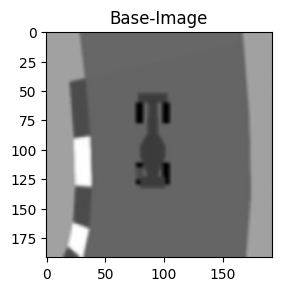

In [6]:
def baseImage(image, sigma, sigma_assumed):

    ## Upsampling the image by 2 in both direction
    upscaled_image = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)

    ## Computing the sigma after applying 2 Gaussian smoothing 
    sigma_diff = np.sqrt(sigma**2 - sigma_assumed**2)

    ## Applying Gaussianblur to the scaled image
    gaussian_blurred_image = cv2.GaussianBlur(upscaled_image,(0,0),sigma_diff)
    
    return gaussian_blurred_image

img = cv2.imread('images/car1.png')
grayscale_img = cv2.imread('images/car1.png', cv2.IMREAD_GRAYSCALE)
base_image = baseImage(grayscale_img, 0.8, 0.5)

plt.subplot(1, 2, 2) 
plt.imshow(base_image, cmap='gray')
plt.title('Base-Image')


### 1.2 Gaussian Scale-Space

The number of octaves is calculated according to the following equation:

$$ \left\lfloor \log_2 (\min(w, h) / \delta_{min} / 12) + 1 \right\rfloor $$

where $w, h$ is the width and height of the image, respectively. The output of this function with the given image is 7



In [7]:
def numOctave(image_shape, delta_min):

    height, width, _ = image_shape
    min_dimension = min(width, height)
    octaves = np.floor(np.log(min_dimension /(delta_min* 12)) + 1)

    return int(octaves)
    
img_shape = img.shape
octaves_count = numOctave(img_shape, 0.015)
print('No. of octaves = ', octaves_count)


No. of octaves =  7


Next, we compute the Gaussian kernels for the images according to number of intervals. 

*Number of intervals S = 3* : According to the paper,  the highest repeatability is obtained when sampling 3 scales per octave. Hence we choose 3 and the total number of images produced in a stack of blurred images is given by *S + 1*, which is 6 in our case.

*Constant factor in scale space k = $2^{1/s}$* : In our case, the k value is 1.26

*σ = 1.6* : This initial value of sigma is choses in the paper as it provides close to optimal repeatability of the features

The incremental blurrimg at each level (from i = 0 to 5) is given by :

$$ \sigma_{\text{i}} = \sqrt{ (\sigma{ k^{i}}) ^ {2}- (\sigma{k^{i-1}}) ^ {2}} $$

In [8]:
def GaussianKernel(num_intervals, sigma):
    
    ## Number of images in the stack
    images_count = num_intervals + 3
    
    ## Calculating k, the scaling between levels
    k =  2 ** (1/num_intervals)

    gaussian_kernels = [sigma]

    ## Calculate the Gaussian kernels
    for i in range(1,images_count) :
        sigma_diff = sqrt((sigma * (k ** i))**2 - (sigma * (k ** (i-1)))**2)
        gaussian_kernels.append(sigma_diff)

    return gaussian_kernels

final_gaussian_kernel = GaussianKernel(3, 1.6)
print('sigma values for Gaussian blur = ', final_gaussian_kernel)

sigma values for Gaussian blur =  [1.6, 1.2262734984654078, 1.5450077936447961, 1.9465878414647129, 2.4525469969308156, 3.0900155872895922]


Next, we use the sigma values from the Gaussian kernels from previous function to create the 6 Gaussian Images for each octave.

Once a complete octave has been processed, we should resample the Gaussian image that has twice the initial σ value for the current octave. This specific image is described as being "2 images from the top of the stack" of blurred images within the current octave. This effectively means it is the second-to-last Gaussian blurred image in the stack of the previous octave is considered for next octave

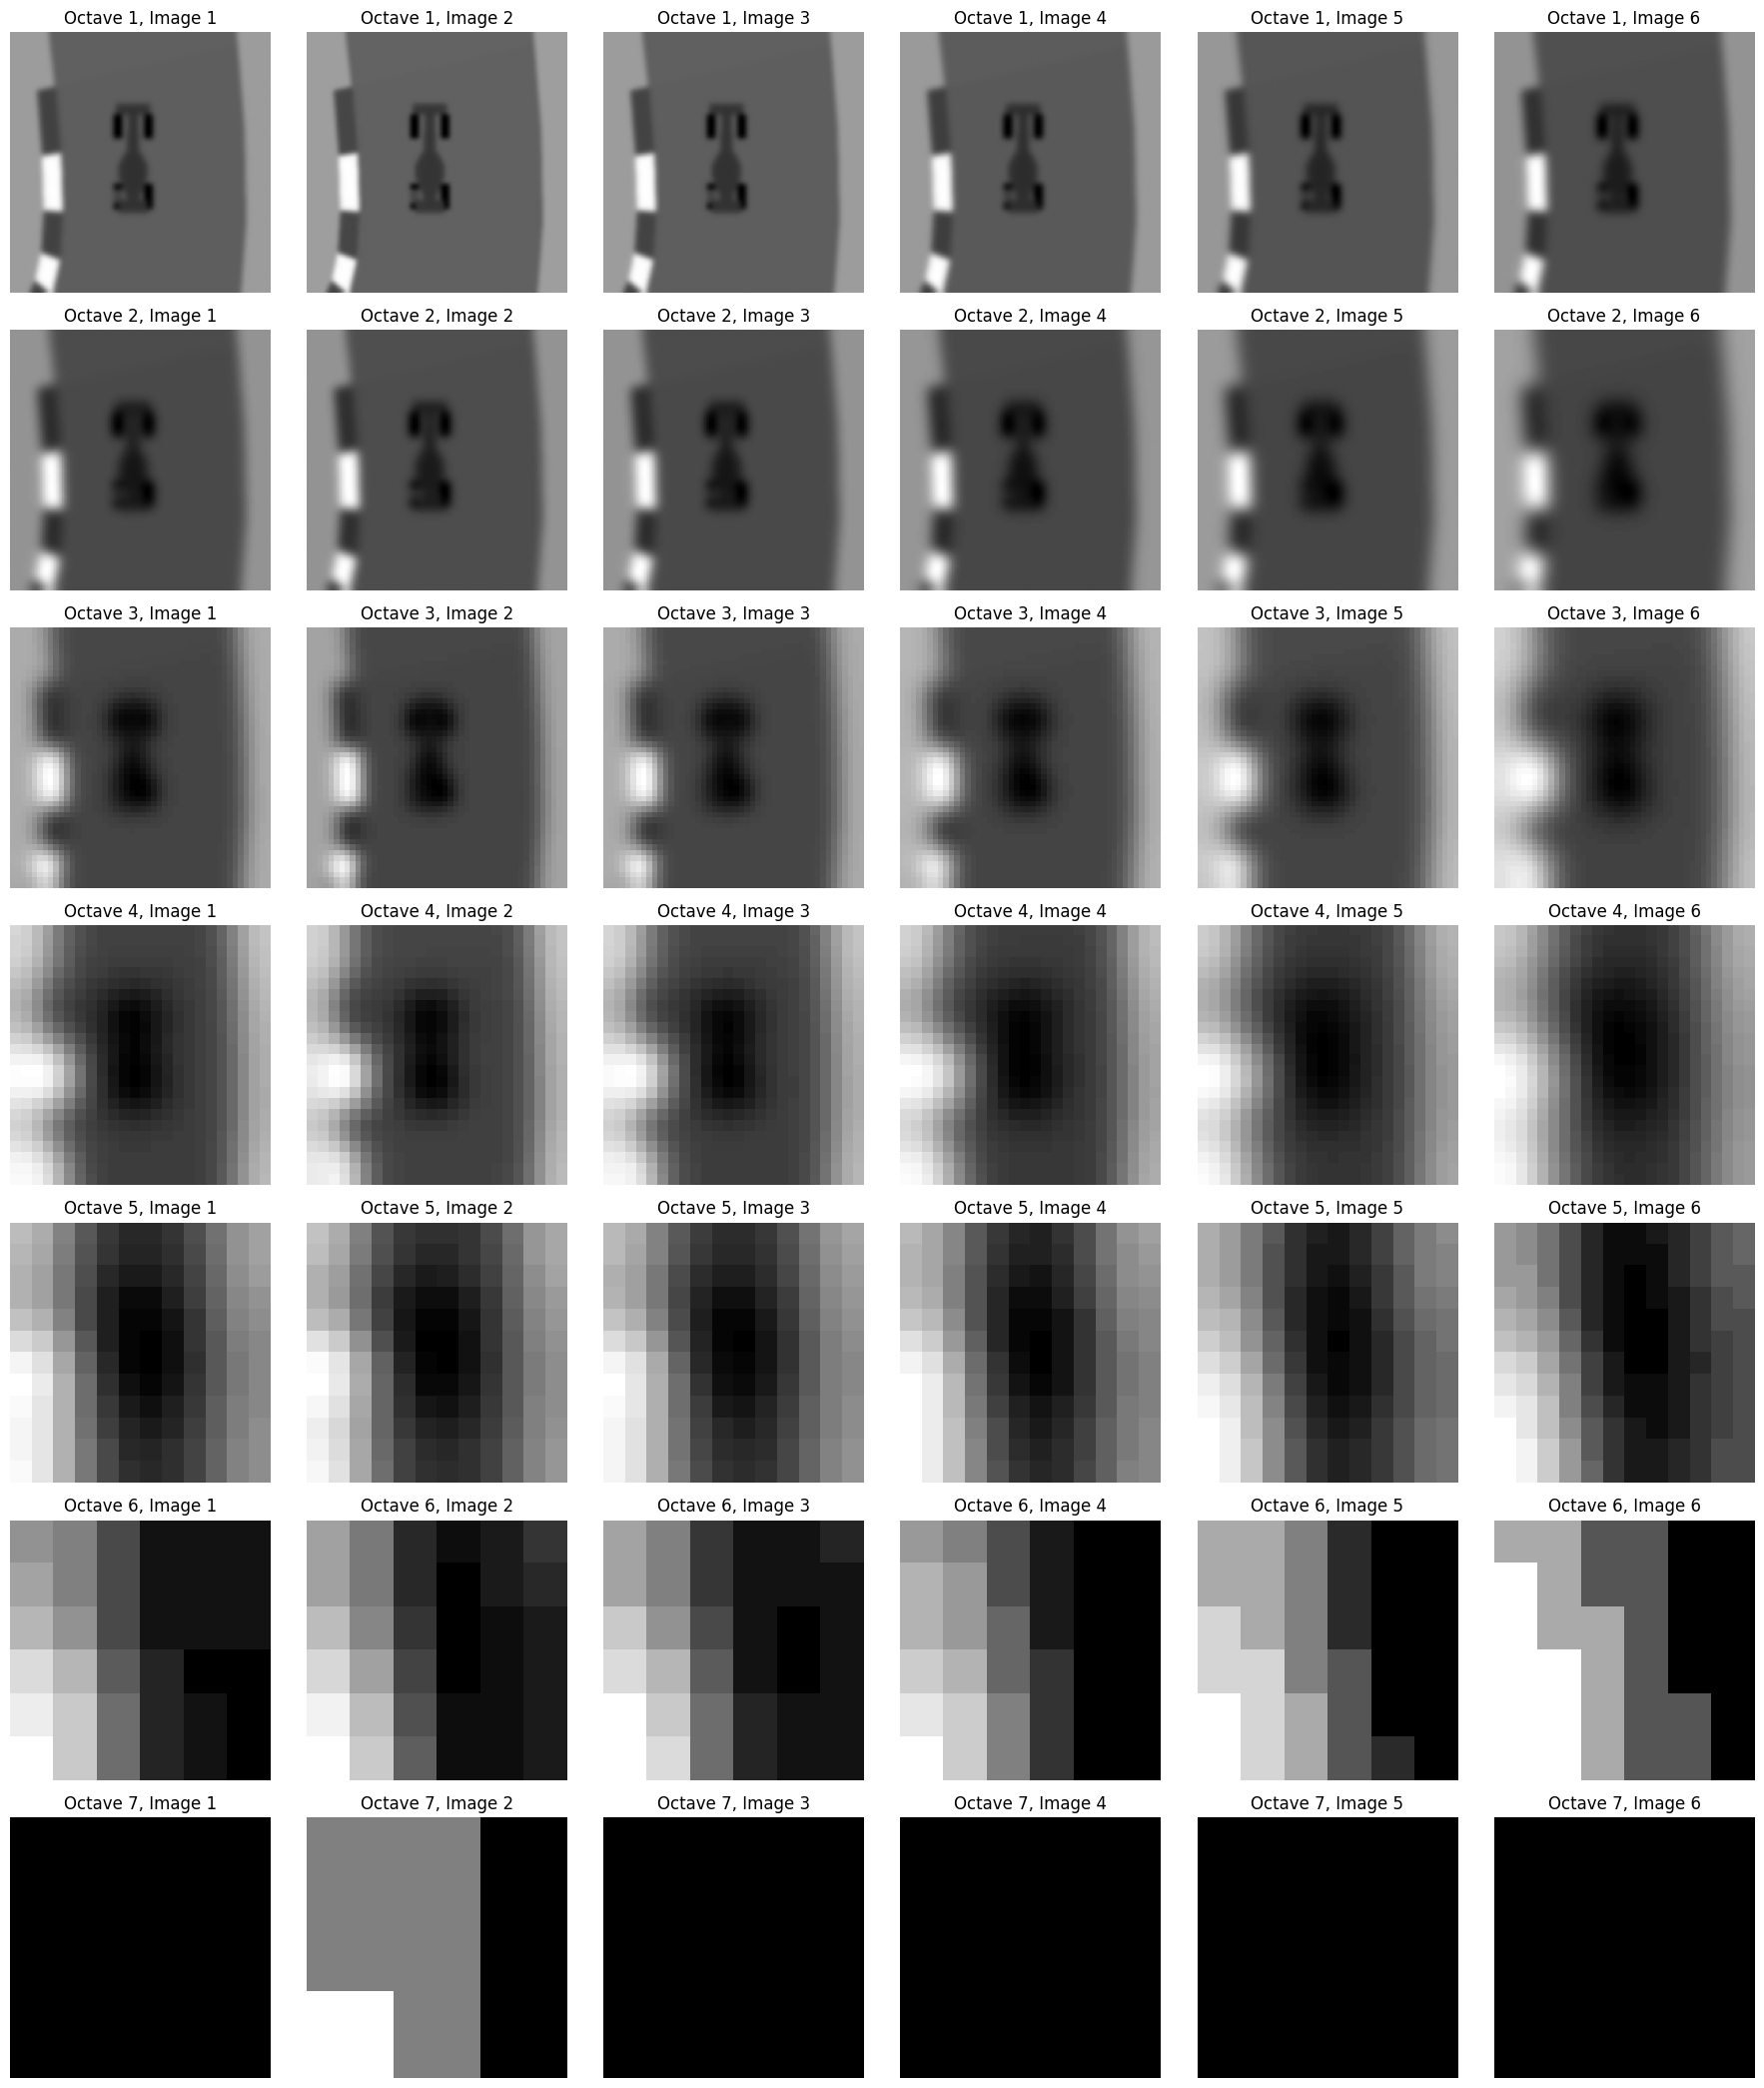

In [9]:
def createGaussianImages(image, num_octaves, gaussian_kernels):
   
    base_Image = image
    gaussian_images_array = []

    ## Loop for num_octaves time and loop through each gaussian kernel    
    for octave in range(num_octaves):
        octave_images = []
        for sigma in range(len(gaussian_kernels)):
            blurred_image = cv2.GaussianBlur(base_Image,(0,0),gaussian_kernels[sigma])
            octave_images.append(blurred_image)
        
        gaussian_images_array.append(octave_images)

        ## prepare base image for the next octave by resize the image by half
        ## Select the 3rd last image. See Figure 2b, anatomy of sift. ~3 lines
        # Use different interpolation for very small images to preserve structure
        interpolation_method = cv2.INTER_LINEAR
        if octave_images[3].shape[0] < 16 or octave_images[3].shape[1] < 16:
            interpolation_method = cv2.INTER_NEAREST

        base_Image = cv2.resize(octave_images[3], None, fx=0.5, fy=0.5, interpolation=interpolation_method)

    return gaussian_images_array

def plotGaussianImages(gaussian_images_array):
    
    num_octaves = len(gaussian_images_array)
    num_levels = len(gaussian_images_array[0])

    fig, axs = plt.subplots(num_octaves, num_levels, figsize=(3*num_levels, 3*num_octaves))

    for i in range(num_octaves):
        for j in range(num_levels):
            ax = axs[i][j] if num_octaves > 1 else axs[j]  # handle 1-octave case
            ax.imshow(gaussian_images_array[i][j], cmap='gray')
            ax.set_title(f"Octave {i+1}, Image {j+1}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

final_gaussian = createGaussianImages(base_image, octaves_count, final_gaussian_kernel)
plotGaussianImages(final_gaussian)


### 1.3 Difference of Gaussian

After blurring images, according to the algorithm, we subtract adjacent blurred images, producing the Difference of Gaussians (DoG) images to identify keypoints.

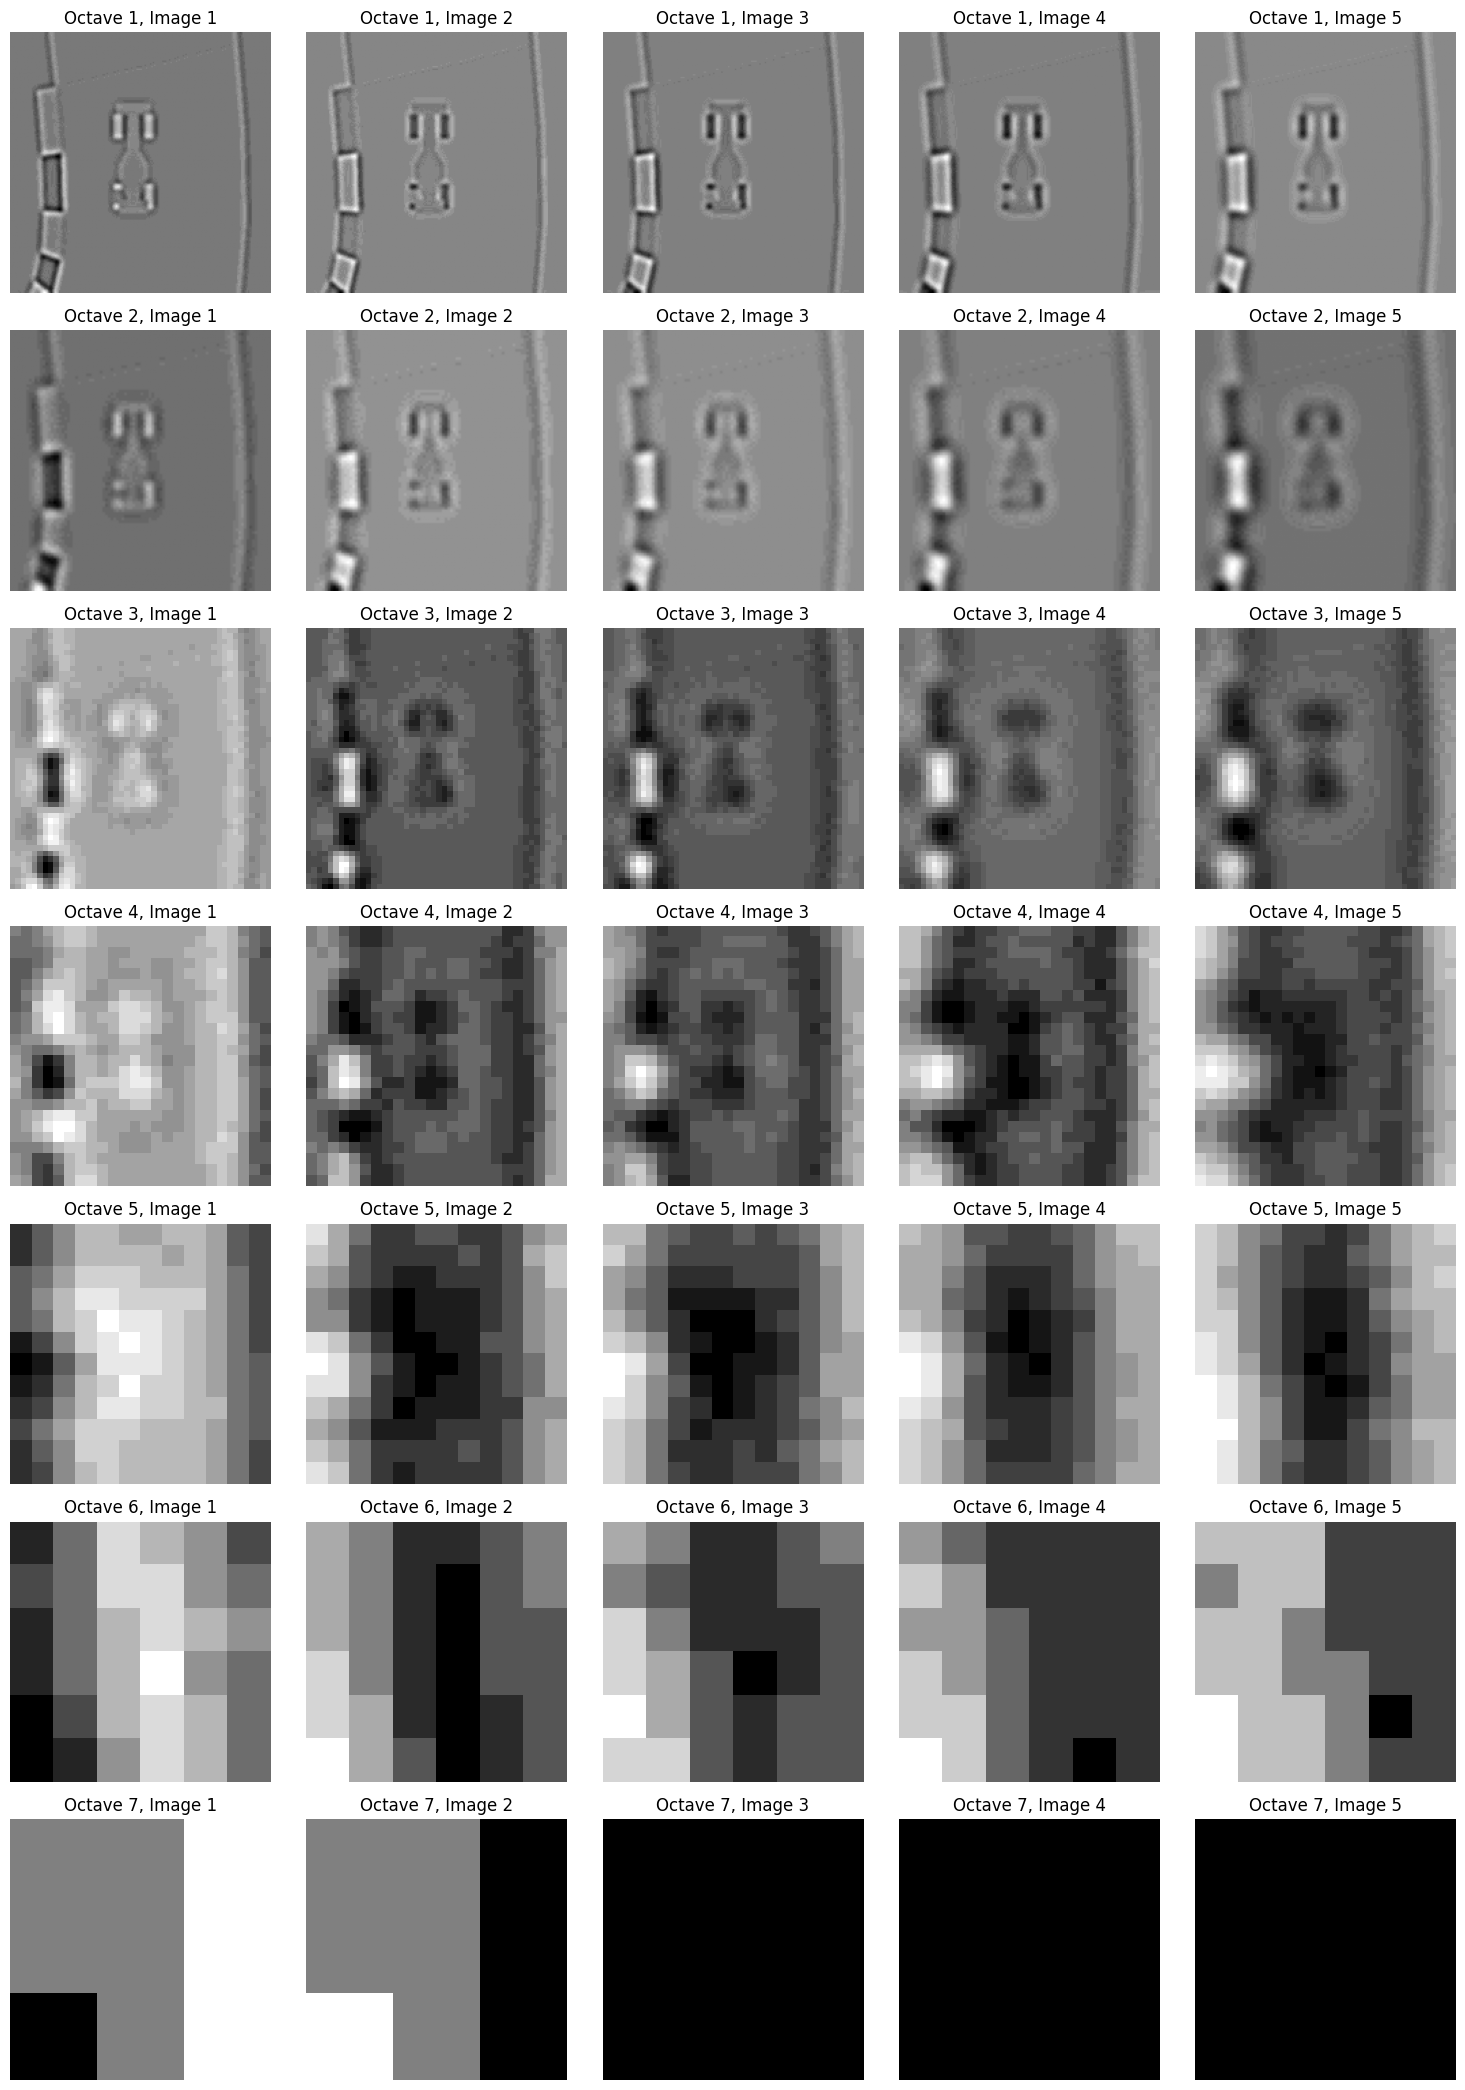

In [10]:
def DoGImages(gaussian_images):
    
    DoG_array =[]
    for octave in gaussian_images:
        DoG_octave = []
        
        for i in range(1, len(octave)):            
            DoG_image = cv2.subtract(octave[i-1].astype(np.float32), octave[i].astype(np.float32))   
            
            DoG_octave.append(DoG_image)
    
        DoG_array.append(DoG_octave)
    
    return np.array(DoG_array, dtype=object)

DoG_final = DoGImages(final_gaussian)
plotGaussianImages(DoG_final)

## Step 2 : Keypoint Localization

### 2.1 Local extrema detection and filter unstable points

We iterate through each pixel in each DoG image across all scales (octaves and levels).
For each pixel, we compare its value to its 8 immediate neighbors in the current 2D slice, and 9 neighbors in the slices directly above and below it (total 26 neighbors). 
If a pixel is a local maximum or minimum (greater/smaller than all its 26 neighbors), we mark it as a candidate keypoint.

In [11]:
def detectLocalExtrema(input_array, threshold):
    
    center_pixel = input_array[1, 1, 1]

    # Flatten the cube and remove the center pixel
    neighbors = input_array.flatten()
    neighbors = np.delete(neighbors, 13)  # center is at index 13 in flattened 3x3x3

    if abs(center_pixel) < threshold:
        return False

    # Check if center is strictly greater or smaller than all neighbors
    if np.all(center_pixel > neighbors):
        return True
    if np.all(center_pixel < neighbors):
        return True

    return False

input_array3 = np.array([[[3, 7, 1], [0, 4, 4], [5, 9, 3]], 
                        [[4, 5, 6], [4, 9, 5], [9, 3, 4]],
                        [[8, 1, 9], [1, 6, 5], [1, 5, 5]]])

Value = detectLocalExtrema(input_array3, 0.015)
print('Extrema found? - ', Value)

Extrema found? -  False


### 2.2 Compute Hessian and Gradient

We compute the elements of Hessian Matrix  and Gradient as per this equation in Anatomy of Sift. 

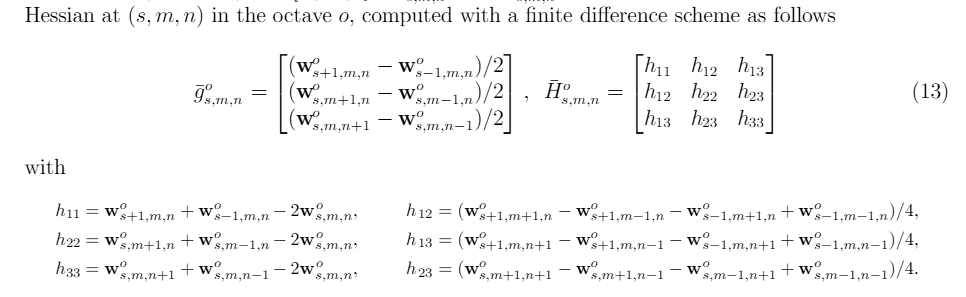

In [12]:
def computeHessian(input_array):
    
    center_pixel = input_array[1, 1, 1]

    # main diagonal
    dxx = input_array[1, 1, 2] + input_array[1, 1, 0] - 2 * center_pixel
    dyy = input_array[1, 2, 1] + input_array[1, 0, 1] - 2 * center_pixel
    dss = input_array[2, 1, 1] + input_array[0, 1, 1] - 2 * center_pixel

    # off-diagonal
    dxy = (input_array[1, 2, 2] - input_array[1, 2, 0] - input_array[1, 0, 2] + input_array[1, 0, 0]) / 4
    dxs = (input_array[2, 1, 2] - input_array[2, 1, 0] - input_array[0, 1, 2] + input_array[0, 1, 0]) / 4
    dys = (input_array[2, 2, 1] - input_array[2, 0, 1] - input_array[0, 2, 1] + input_array[0, 0, 1]) / 4

    return np.array([[dxx, dxy, dxs],
                     [dxy, dyy, dys],
                     [dxs, dys, dss]])


In [13]:
def computeGradient(input_array):
    
    dx = (input_array[1, 1, 2] - input_array[1, 1, 0]) / 2
    dy = (input_array[1, 2, 1] - input_array[1, 0, 1]) / 2
    dz = (input_array[2, 1, 1] - input_array[0, 1, 1]) / 2
    
    return np.array([dx, dy, dz])

In [14]:
# Testing the functions for a given input_array

input_array = np.array([[[3, 7, 1], [0, 4, 4], [5, 9, 3]], 
                        [[4, 5, 6], [4, 1, 5], [9, 3, 4]],
                        [[8, 1, 9], [1, 6, 5], [1, 5, 5]]])

print('Hessian Matrix : ', computeHessian(input_array))
print('Gradient : ', computeGradient(input_array))

Hessian Matrix :  [[ 7.   -1.75  0.  ]
 [-1.75  6.    0.5 ]
 [ 0.    0.5   8.  ]]
Gradient :  [ 0.5 -1.   1. ]


### 2.3 Keypoint Quadratic Interpolation

In [15]:
def keyPointInterpolation(i, j, image_index, dog_images, image_border_width, num_intervals, max_attempts=5):
    
    extremum_is_outside_image = False
    image_shape = dog_images[0].shape
    

    ## Repeat the algorithm for 5 times or until the max() <= 0.5
    for attempt in range(max_attempts):
        ## Extract three adjacent scale images
        current_scale_image = np.array(dog_images[image_index])
        upper_scale_image = np.array(dog_images[image_index + 1])
        lower_scale_image = np.array(dog_images[image_index - 1])
        

        # Stack the pixel values into a cube and normalize them to the range [0, 1]
        image_cube = np.stack((lower_scale_image[i-1:i+2,j-1:j+2]
                               ,current_scale_image[i-1:i+2,j-1:j+2], 
                               upper_scale_image[i-1:i+2,j-1:j+2]), axis=0).astype(np.float32) 
        
    
        ## Compute Gradient and Hessian using the functions implemented above
        hessian = computeHessian(image_cube)
        gradient = computeGradient(image_cube)

    
        ## Solve for the offset vector using least squares numpy lstsq
        try:
            # Least-squares solution to H * offset = -gradient
            offset = -np.linalg.lstsq(hessian, gradient, rcond=None)[0]
        except np.linalg.LinAlgError:
            return None, None, None, None, None  # Singular Hessian
        
        ## Check if the offset displacement is small enough to stop refining
        if np.all(np.abs(offset) < 0.5):
            break

        ## Update keypoint coordinates and scale index based on estimated offset
        j += int(round(offset[0]))
        i += int(round(offset[1]))
        image_index += int(round(offset[2]))

        ## Make sure the new pixel_cube will lie entirely within the image
        if (image_index < 1 or image_index > num_intervals or
            i < image_border_width or i >= image_shape[0] - image_border_width or
            j < image_border_width or j >= image_shape[1] - image_border_width):
            extremum_is_outside_image = True
            break
        
    ## Check whether extremum lies outside image or too many number of attempts and return None
    if extremum_is_outside_image or np.any(np.abs(offset) >= 1.5):
        return None, None, None, None, None
    
    ## If OK, compute the interpolated center point
    interpolated_value = image_cube[1, 1, 1] + 0.5 * np.dot(gradient, offset)

    return i, j, image_index, offset, interpolated_value
     
for i in range(1,len(DoG_final[0])-1):
    i_value, j_value, image_index, offset, interpolated_value = keyPointInterpolation(1,1,i,DoG_final[0],3,3,5) #calling the function only for first Octave for testing
    print('i_value', i_value)
    print('j value', j_value)
    print('image index', image_index)
    print('offset', offset)
    print('interpolated_value',interpolated_value)


i_value 1
j value 1
image index 1
offset [-0. -0. -0.]
interpolated_value 0.0
i_value 1
j value 1
image index 2
offset [-0. -0. -0.]
interpolated_value 0.0
i_value 1
j value 1
image index 3
offset [-0. -0. -0.]
interpolated_value 0.0


### 2.4 Filter Keypoints on Edge

This step is to eliminate the poorly determined edges ( the ones with large principal curvature across edge but small in the perpendicular direction). The principal curvature can be computed from 2x2 Hessian Matrix.

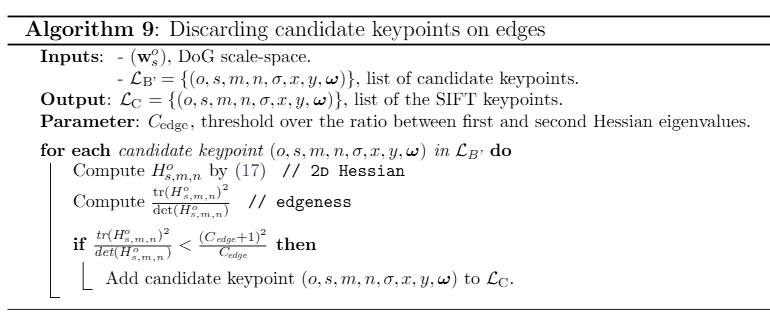 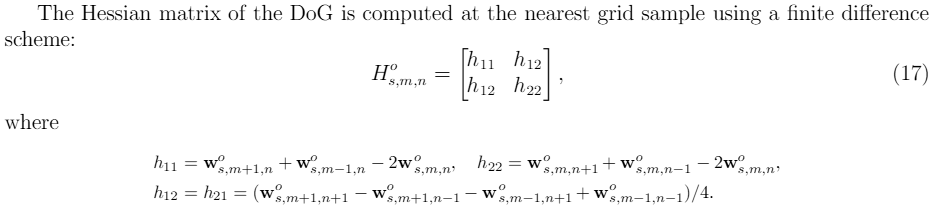

In [16]:
def filterKeypoints_edge(center_hessian, C_edge):
    
    ## TODO: implement section 4.1 of [1]
    
    # h11 = image_cube[1,2,1] + image_cube[1,0,1] - 2 * image_cube[1,1,1]
    # h22 = image_cube[1,1,2] + image_cube[1,1,0] - 2 * image_cube[1,1,1]
    # h12 = (image_cube[1,2,2] - image_cube[1,2,0] - image_cube[1,0,2] + image_cube[1,0,0])/4

    # hessian_2_x_2 = np.array([[h11, h12],
    
    ## Extract 2x2 hessian matrix
    H_spatial = center_hessian[1:, 1:]  # 2x2 Hessian is the bottom right submatrix of 3x3 Hessian
    
    # Compute trace and determinant
    trace_H = np.trace(H_spatial)
    det_H = np.linalg.det(H_spatial)

    # Avoid division by zero or unstable computation
    if det_H <= 0:
        return False

    # Compute edge response ratio
    edge_response = (trace_H ** 2) / det_H
    threshold = ((C_edge + 1) ** 2) / C_edge

    # Return True if keypoint passes the edge filter
    return edge_response < threshold
   
input_array3 = np.array([[[3, 7, 1], [0, 4, 4], [5, 9, 3]], 
                        [[4, 5, 6], [4, 9, 5], [9, 3, 4]],
                        [[8, 1, 9], [1, 6, 5], [1, 5, 5]]])
center_Hessian = computeHessian(input_array3)

print(filterKeypoints_edge(center_Hessian, 10))


True


## Step 3: Orientation Assignment

### 3.1 Keypoint Reference Orientation

In [17]:
def keypoints_with_orientations(
    keypoint, octave_index, gaussian_image,
    radius_factor=3, num_bins=36,
    peak_ratio=0.8, scale_factor=1.5
    ):
    """
    Assigns orientation(s) to a detected keypoint based on local image gradients.
    Multiple orientations may be assigned if strong peaks exist.
    Inputs:
        - keypoint: cv2.KeyPoint object from DoG keypoint detection
        - octave_index: the current octave level in the pyramid
        - gaussian_image: corresponding Gaussian-blurred image
        - radius_factor: how far out to sample gradients (relative to scale)
        - num_bins: number of bins in orientation histogram. Default: 36 (10° per bin)
        - peak_ratio: secondary peak threshold relative to max. Default: 0.8
        - scale_factor: relates scale of keypoint to image resolution.
    Output:
        - List of cv2.KeyPoint objects with assigned orientation(s).
    """

    image_height, image_width = gaussian_image.shape
    
    ## Scale the window size around the keypoint based on its size and octave
    scale = scale_factor * keypoint.size / (2 ** (octave_index + 1))

    ## Compute window radius for sampling gradient vectors
    radius = int(round(radius_factor * scale))
    
    ## Gaussian weight factor used for weighting gradient magnitudes based on distance from keypoint
    weight_sigma = 1.5 * scale
    weight_factor = -0.5 / (weight_sigma ** 2)

    ## Get keypoint position at this octave's resolution
    x, y = int(round(keypoint.pt[0])), int(round(keypoint.pt[1]))
    
    ## Initialize the orientation histogram (e.g. 36 bins for 360°)
    histogram = np.zeros(num_bins, dtype=np.float32)

    ## Iterate over square window centered at the keypoint
    for i in range(-radius, radius + 1):
        region_y = y + i
        if region_y <= 0 or region_y >= image_height - 1:
            continue
        for j in range(-radius, radius + 1):
            region_x = x + j
            if region_x <= 0 or region_x >= image_width - 1:
                continue

            ## Compute gradient using central differences
            dx = float(gaussian_image[region_y, region_x + 1]) - float(gaussian_image[region_y, region_x - 1])
            dy = float(gaussian_image[region_y - 1, region_x]) - float(gaussian_image[region_y + 1, region_x])

            ## Compute gradient magnitude and orientation
            magnitude = np.sqrt(dx ** 2 + dy ** 2)
            orientation = np.degrees(np.arctan2(dy, dx)) % 360

            ## Apply Gaussian weighting based on distance from keypoint
            weight = np.exp(weight_factor * (i ** 2 + j ** 2))
            weighted_magnitude = weight * magnitude

            ## Bin index corresponding to orientation
            bin_idx = int(round(orientation * num_bins / 360.)) % num_bins

            ## Add weighted magnitude to the appropriate bin 
            histogram[bin_idx] += weighted_magnitude
    
    ## Smooth the histogram 
    smooth_hist = (
        6 * histogram +
        4 * (np.roll(histogram, 1) + np.roll(histogram, -1)) +
        np.roll(histogram, 2) + np.roll(histogram, -2)
    ) / 16.

    orientations = []
    
    ## Find max peak value
    max_peak = np.max(smooth_hist)

    ## Find histogram peaks that are greater than neighbors and above threshold
    
    ## Loop through the peaks
    for bin_idx in range(num_bins):
        prev = smooth_hist[bin_idx - 1]
        next = smooth_hist[(bin_idx + 1) % num_bins]
        current = smooth_hist[bin_idx]

        if current > prev and current > next and current >= peak_ratio * max_peak:
            # Parabolic interpolation
            l = prev
            c = current
            r = next
            offset = 0.5 * (l - r) / (l - 2 * c + r)

            ## Convert bin to angle (0–360°), clockwise
            ## Normalize 360° to 0°
            theta = ((bin_idx + offset) * 360. / num_bins) % 360

            new_kp = cv2.KeyPoint(
                x=keypoint.pt[0], y=keypoint.pt[1],
                size=keypoint.size,
                angle=theta,
                response=keypoint.response,
                octave=keypoint.octave
            )
            orientations.append(new_kp)
    
    return orientations

### 3.2 Keypoint Localization

Detected keypoints:  31


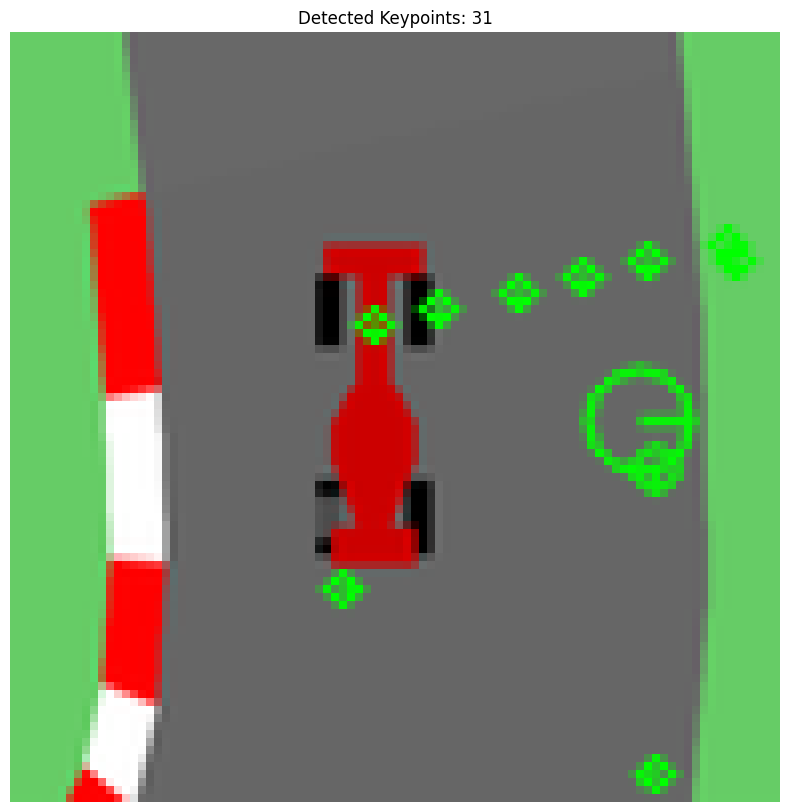

In [18]:
def keyPointLocalization(gaussian_images, dog_pyramid, num_intervals=3, sigma=1.6, image_border_width=5, contrast_threshold=0.005):
    """
    Using the functions in section 2 and 3.1 to find the keypoints in the image
    Inputs:
        - gaussian_images: list of gaussian images
        - dog_pyramid: DoG images
        - num_interval: Number of intervals per octave
        - sigma: sigma in Gaussian kernel. Default: 1.6
        - image_border_width: Minimum allowed distance from image borders
        - contrast_threshold: threshold used in opencv
    Outputs:
        - keypoints with orientation: cv2.KeyPoint() object
    """
    ## TODO:
    keypoints = []    
    ## Ref: https://github.com/opencv/opencv/blob/b3cb517cac817dfa6248deea510a73f0c14ca963/modules/features2d/src/sift.dispatch.cpp#L374
    threshold = np.floor(0.5 * contrast_threshold / num_intervals * 255)
    
    for octave_index, dog_octave in enumerate(dog_pyramid):
        for image_index in range(1, num_intervals + 1):  # Exclude first and last images
            dog_image = dog_octave[image_index]
            height, width = dog_image.shape


            for i in range(image_border_width, height - image_border_width):
                for j in range(image_border_width, width - image_border_width):
                    pixel_cube = np.stack([
                        dog_octave[image_index - 1][i - 1:i + 2, j - 1:j + 2],
                        dog_octave[image_index][i - 1:i + 2, j - 1:j + 2],
                        dog_octave[image_index + 1][i - 1:i + 2, j - 1:j + 2]
                    ], axis=0).astype(np.float32) 

                    if not detectLocalExtrema(pixel_cube, threshold):
                        continue

                    # Interpolation
                    interp_result = keyPointInterpolation(
                        i, j, image_index, dog_octave,
                        image_border_width, num_intervals
                    )
                    
                    if interp_result[0] is None:
                        continue

                    i_interp, j_interp, image_index_interp, offset, contrast = interp_result
                    

                    # if abs(contrast) < threshold:
                    #     continue

                    hessian = computeHessian(pixel_cube)
                   

                    if not filterKeypoints_edge(hessian,10):
                        continue

                    # Create cv2.KeyPoint object
                    scale = sigma * (2 ** (image_index_interp / num_intervals)) * (2 ** octave_index)
                
                    keypoint = cv2.KeyPoint()
                    keypoint.pt = (j_interp * (2 ** octave_index), i_interp * (2 ** octave_index))
                    keypoint.octave = octave_index + (image_index_interp << 8)
                    keypoint.size = scale * 2  # diameter
                    keypoint.response = abs(contrast)

                    # Assign orientation(s)
                    oriented_kps = keypoints_with_orientations(
                        keypoint, octave_index,
                        gaussian_images[octave_index][image_index_interp]
                    )
                    
                    keypoints.extend(oriented_kps)

    return keypoints

keypoints = keyPointLocalization(final_gaussian,DoG_final,3,1.6,5,0.005)
print("Detected keypoints: ",len(keypoints))


output_image = cv2.drawKeypoints(
    img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    color=(0, 255, 0)
)

# Display using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(output_image[..., ::-1])  # Convert BGR to RGB
plt.title(f"Detected Keypoints: {len(keypoints)}")
plt.axis("off")
plt.show()


## Step 4: Keypoint Descriptor

### 4.2 Generate Descriptor

In [19]:
def unpackOctave(keypoint):
    """
    Unpack octave, layer, and scale from a keypoint.octave field.
    OpenCV packs the octave and layer into a single integer using bit manipulation.
    This function extracts:
        - octave: pyramid level (may be negative if image was upsampled)
        - layer: layer index within the octave
        - scale: the resolution scale relative to the original image
    Inputs:
        - keypoint: a cv2.KeyPoint 
    Outputs:
        - tuple: (octave, layer, scale)
    """
    # Extract lower 8 bits as octave
    octave = keypoint.octave & 255    
    # Extract next 8 bits as layer
    layer = (keypoint.octave >> 8) & 255    
    # Convert octave to signed value if necessary
    if octave >= 128:
        octave = octave | -128  # Sign extension to handle negative octaves
    # Compute scale from octave
    scale = 1 / np.float32(1 << octave) if octave >= 0 else np.float32(1 << -octave)

    return octave, layer, scale

In [20]:
def generate_descriptors(keypoints, gaussian_images, window_width=4, num_bins=8, scale_multiplier=3, descriptor_max_value=0.2):
    """
    Generate orientation histograms around each keypoint to create SIFT-like descriptors.
    Inputs:
        - keypoints: list of detected keypoints with orientation
        - gaussian_images: Gaussian-blurred images
        - window_width: Width of the grid of histograms. Default: 4
        - num_bins: Number of orientation bins in each histogram. Default: 8
        - scale_multiplier: Controls spatial extent of the descriptor window. Default: 2
        - descriptor_max_value: Threshold for descriptor vector normalization. Default: 0.2
    Outputs:
        - Array of float32 descriptors, np.ndarray
    """
    descriptors = []
    bins_per_degree = num_bins / 360.
    weight_sigma = 0.5 * window_width
    weight_multiplier = -0.5 / (weight_sigma ** 2)

    ## TODO: loop through the keypoints

    for keypoint in keypoints:
        ## Unpack the keypoint's scale-space position using the provided function
        octave, layer, scale = unpackOctave(keypoint)
        ## Select corresponding Gaussian image
        gaussian_image = gaussian_images[octave][layer]
        ## Convert keypoint location (.pt) to pixel coords in current scale
        kp_x, kp_y = keypoint.pt[0] / (2 ** octave), keypoint.pt[1] / (2 ** octave)
        ## Rotate gradient directions relative to keypoint angle
        angle = np.deg2rad(keypoint.angle)
        
        cos_angle = np.cos(angle)
        sin_angle = np.sin(angle)

        ## Initialize histogram grid with extra border (2)
        hist_width = scale_multiplier * keypoint.size / (2 ** octave)
        radius = int(np.round(hist_width * np.sqrt(2) * (window_width + 1) * 0.5))
        bins = np.zeros((window_width, window_width, num_bins))

        height, width = gaussian_image.shape

        ## Iterate over pixels in descriptor window
        for i in range(-radius, radius + 1):
            for j in range(-radius, radius + 1):
                # Rotated coordinates
                rot_x = (cos_angle * j - sin_angle * i) / hist_width
                rot_y = (sin_angle * j + cos_angle * i) / hist_width
                ## Map to histogram bin coordinates
                bin_x = rot_x + window_width / 2 - 0.5
                bin_y = rot_y + window_width / 2 - 0.5

                ## Skip if out of histogram grid
                if bin_x < 0 or bin_x >= window_width - 1 or bin_y < 0 or bin_y >= window_width - 1:
                    continue

                ## Compute image gradients
                img_x = int(round(kp_x + j))
                img_y = int(round(kp_y + i))

                if img_y <= 0 or img_y >= height - 1 or img_x <= 0 or img_x >= width - 1:
                    continue

                dx = gaussian_image[img_y, img_x + 1] - gaussian_image[img_y, img_x - 1]
                dy = gaussian_image[img_y - 1, img_x] - gaussian_image[img_y + 1, img_x]
                magnitude = np.sqrt(dx ** 2 + dy ** 2)
                orientation = np.rad2deg(np.arctan2(dy, dx)) % 360
                relative_orientation = (orientation - np.rad2deg(angle)) % 360
                bin_orientation = relative_orientation * bins_per_degree

                # Weight with Gaussian window
                weight = np.exp(weight_multiplier * ((rot_x) ** 2 + (rot_y) ** 2))
                weighted_magnitude = weight * magnitude

                ## Interpolate magnitude to 8 neighboring bins in 3D
                x0 = int(np.floor(bin_x))
                y0 = int(np.floor(bin_y))
                o0 = int(np.floor(bin_orientation)) % num_bins

                dx_bin = bin_x - x0
                dy_bin = bin_y - y0
                do_bin = bin_orientation - o0

                for m in range(2):
                    for n in range(2):
                        for k in range(2):
                            x_idx = x0 + m
                            y_idx = y0 + n
                            o_idx = (o0 + k) % num_bins

                            if x_idx < 0 or x_idx >= window_width or y_idx < 0 or y_idx >= window_width:
                                continue

                            weight_interp = ((1 - dx_bin) if m == 0 else dx_bin) * \
                                            ((1 - dy_bin) if n == 0 else dy_bin) * \
                                            ((1 - do_bin) if k == 0 else do_bin)

                            bins[y_idx, x_idx, o_idx] += weight_interp * weighted_magnitude

        # Flatten and normalize the descriptor
        descriptor_vector = bins.flatten()
        norm = np.linalg.norm(descriptor_vector)

        if norm > 1e-7:
            descriptor_vector /= norm
            descriptor_vector = np.clip(descriptor_vector, 0, descriptor_max_value)
            descriptor_vector /= np.linalg.norm(descriptor_vector)

        ## Scale and quantize to 8-bit values (OpenCV uses 512 multiplier)
        descriptor_vector = np.round(512 * descriptor_vector)
        descriptor_vector = np.clip(descriptor_vector, 0, 255)
        descriptors.append(descriptor_vector.astype(np.uint8))
    
    return np.array(descriptors, dtype=np.float32)


### 4.3 Generate Keypoints and Descriptors

In [21]:
def generate_keypoints_descriptors(image):
    """
    Putting the above equations in the correct order to create keypoints and descriptors
    Inputs:
        - image: input images
    Outputs:
        - keypoints: list of cv2.KeyPoints object
        - descriptors: numpy array contains all the descriptors
    """
    ## TODO: Pay attention to the order of the functions above

    # STEP 1 : Scale Space Extrema Detection
    base_image = baseImage(image,0.8,0.5)
    octaves_count = 7
    gaussian_kernels = GaussianKernel(3,1.6)
    gaussian_images = createGaussianImages(image,octaves_count,gaussian_kernels)
    DoG_pyramid = DoGImages(gaussian_images)

    # STEP 2 : Keypoint Localization
    keypoints = keyPointLocalization(gaussian_images,DoG_pyramid,3,1.6,5,0.005)

    # STEP 3 : Generate Descriptors
    descriptors = generate_descriptors(keypoints,gaussian_images,4,8,3,0.2)

    return keypoints, descriptors


## Step 5 : Matching

In [22]:
def euclidean_dist(desc1, desc2):
    """
    Compute Euclidean distance between two descriptors
    """
    return np.linalg.norm(np.array(desc1) - np.array(desc2))

def find_keypoint_matches(descriptor1, descriptor2, thresh_relative=0.7, thresh_absolute=350):
    """
    Find keypoint matches between descriptor 1 and 2 using ratio test.
    Inputs:
        - descriptor1: descriptor of image 1, numpy array
        - descriptor2: descriptor of image 2, numpy array
        - thresh_relative: Lowe's ratio threshold to determine if a match is valid. Default: 0.7
        - thresh_absolute: Absolute threshold to remove weak matches. Default: 350
    Outputs:
        - matches: List of tuples (index of descriptor1, index of matching descriptor2)
    """
    assert len(descriptor1) >= 2 and len(descriptor2) >= 2

    matches = []

    ## TODO
    ## Loop throught descriptor 1
    for i, desc1 in enumerate(descriptor1):
        distances = []

        ## Loop throught descriptor 2. ~ 8 lines
        for j, desc2 in enumerate(descriptor2):
            dist = np.linalg.norm(desc1 - desc2)
            distances.append((dist, j))

        ## Apply Lowe's ratio test: ensuring the best match is significantly better than the second-best
        distances.sort()
        best_dist, best_j = distances[0]
        second_best_dist = distances[1][0]

        # Apply ratio test and absolute threshold
        if best_dist < thresh_relative * second_best_dist and best_dist < thresh_absolute:
            matches.append((i, best_j))

    return matches

def draw_matches(image1, image2, keypoints1, keypoints2, matches):
    """
    Draws matches between two images with keypoints.
    """
    offset = 25
    # Ensure both images are in 3-channel RGB
    if len(image1.shape) == 2 or image1.shape[2] == 1:
        image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2BGR)
    if len(image2.shape) == 2 or image2.shape[2] == 1:
        image2 = cv2.cvtColor(image2, cv2.COLOR_GRAY2BGR)

    # Combine images side by side
    height = max(image1.shape[0], image2.shape[0]) + offset ## some offset
    width = image1.shape[1] + image2.shape[1] + offset ## some offset
    result = np.zeros((height, width, 3), dtype=np.uint8)
    result[:image1.shape[0], :image1.shape[1]] = image1
    result[offset:offset+image2.shape[0], image1.shape[1] + offset:] = image2

    # Draw lines between matched keypoints
    for idx_1, idx_2 in matches:
        kp_1 = keypoints1[idx_1]
        kp_2 = keypoints2[idx_2]

        pt_1 = (int(kp_1.pt[0]), int(kp_1.pt[1]))
        pt_2 = (int(kp_2.pt[0]) + image1.shape[1] + offset, int(kp_2.pt[1]) + offset)  # Offset x by width of image1
        
        color = tuple(np.random.randint(0, 255, size=3).tolist())
        cv2.circle(result, pt_1, radius=2, color=(255, 255, 0))
        cv2.circle(result, pt_2, radius=2, color=(255, 255, 0))
        cv2.line(result, pt_1, pt_2, color, 1, cv2.LINE_AA)

    plt.imshow(result)

C:\Users\Manasa P\AppData\Local\Temp\ipykernel_24856\1784511059.py:62: RuntimeWarning: overflow encountered in scalar subtract
  dx = gaussian_image[img_y, img_x + 1] - gaussian_image[img_y, img_x - 1]
C:\Users\Manasa P\AppData\Local\Temp\ipykernel_24856\1784511059.py:64: RuntimeWarning: overflow encountered in scalar add
  magnitude = np.sqrt(dx ** 2 + dy ** 2)
C:\Users\Manasa P\AppData\Local\Temp\ipykernel_24856\1784511059.py:63: RuntimeWarning: overflow encountered in scalar subtract
  dy = gaussian_image[img_y - 1, img_x] - gaussian_image[img_y + 1, img_x]


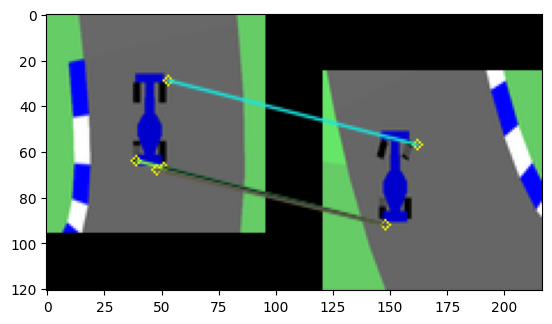

In [23]:
image1 = cv2.imread('images/car1.png')
image2 = cv2.imread('images/car2.png')

gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2= cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

## generate_keypoints_descriptors to be completed above
kp1, des1 = generate_keypoints_descriptors(gray1)
kp2, des2 = generate_keypoints_descriptors(gray2)

## find_keypoint_matches to be completed above
matches = find_keypoint_matches(des1, des2)

draw_matches(image1, image2, kp1, kp2, matches)